# Fetching Data

In [ ]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry


locations_data = {
    'agartala': (23.8361, 91.2794),
    'bikaner':(28.0176, 73.3149), 
    'bengaluru':(12.9719, 77.5937), 
    'chennai':(13.0878, 80.2785),
    'jaisalmer':(26.9176, 70.9039),
    'leh':(34.165, 77.584),
    'lucknow':(26.8393, 80.9231),
    'mumbai':(19.0728, 72.8826),
    'new delhi':(28.6214, 77.2148),
    'shimla':(31.1044, 77.1666)
    }

for location, (lat, lon) in locations_data.items():

    # first we get the forecast data for the location and save it to a csv file

    # setup the Open-Meteo API client with cache and retry on error
    cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
    retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
    openmeteo = openmeteo_requests.Client(session = retry_session)


    # retrieving the hourly forecast data 
    url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2025-01-01",
        "end_date": "2025-12-31",
        "hourly": ["wind_speed_10m", "wind_direction_10m"],
        "wind_speed_unit": "ms",
    }
    responses = openmeteo.weather_api(url, params = params)
    response = responses[0]
    hourly = response.Hourly()
    hourly_wind_speed_10m = hourly.Variables(0).ValuesAsNumpy()
    hourly_wind_direction_10m = hourly.Variables(1).ValuesAsNumpy()

    hourly_data = {"date": pd.date_range(
        start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
        end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	    freq = pd.Timedelta(seconds = hourly.Interval()),
	    inclusive = "left"
    )}
    hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
    hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
    hourly_dataframe = pd.DataFrame(data = hourly_data)
    hourly_dataframe.to_csv(f"data/raw/{location}_forecast.csv", index = False)


    # now we get the actual weather data for the location and save it
    # reinitializing the API
    cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
    retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
    openmeteo = openmeteo_requests.Client(session = retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    responses = openmeteo.weather_api(url, params = params)

    response = responses[0]
    hourly = response.Hourly()
    hourly_wind_speed_10m = hourly.Variables(0).ValuesAsNumpy()
    hourly_wind_direction_10m = hourly.Variables(1).ValuesAsNumpy()

    hourly_data = {"date": pd.date_range(
        start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
        end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
        freq = pd.Timedelta(seconds = hourly.Interval()),
        inclusive = "left"
    )}

    hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
    hourly_data["wind_direction_10m"] = hourly_wind_direction_10m

    hourly_dataframe = pd.DataFrame(data = hourly_data)
    hourly_dataframe.to_csv(f"data/raw/{location}_actual.csv", index = False)
    

The raw forecast and actual data files of a particular `location` are saved as `{location}_forecast.csv` and `{location}_actual.csv`. in the `data/raw/` folder.

### Data Inspection

In [2]:
test_df=pd.read_csv('bengaluru_actual.csv')
test_df

,date,wind_speed_10m,wind_direction_10m
0,2025-01-01 00:00:00+00:00,3.084234,70.096160
1,2025-01-01 01:00:00+00:00,3.166228,68.702576
2,2025-01-01 02:00:00+00:00,3.036445,72.758450
3,2025-01-01 03:00:00+00:00,2.934706,76.200490
4,2025-01-01 04:00:00+00:00,3.510698,79.330270
...,...,...,...
8755,2025-12-31 19:00:00+00:00,1.972308,120.465460
8756,2025-12-31 20:00:00+00:00,1.408013,83.884590
8757,2025-12-31 21:00:00+00:00,2.055480,94.184840
8758,2025-12-31 22:00:00+00:00,1.767767,98.130020


In [3]:
# m/s to km/h conversion factor is 3.6
conversion_factor = 3.6
test_df['wind_speed_10m_kmh'] = test_df['wind_speed_10m'] * conversion_factor
test_df


,date,wind_speed_10m,wind_direction_10m,wind_speed_10m_kmh
0,2025-01-01 00:00:00+00:00,3.084234,70.096160,11.103243
1,2025-01-01 01:00:00+00:00,3.166228,68.702576,11.398421
2,2025-01-01 02:00:00+00:00,3.036445,72.758450,10.931203
3,2025-01-01 03:00:00+00:00,2.934706,76.200490,10.564942
4,2025-01-01 04:00:00+00:00,3.510698,79.330270,12.638512
...,...,...,...,...
8755,2025-12-31 19:00:00+00:00,1.972308,120.465460,7.100310
8756,2025-12-31 20:00:00+00:00,1.408013,83.884590,5.068846
8757,2025-12-31 21:00:00+00:00,2.055480,94.184840,7.399730
8758,2025-12-31 22:00:00+00:00,1.767767,98.130020,6.363961


<Axes: ylabel='Density'>

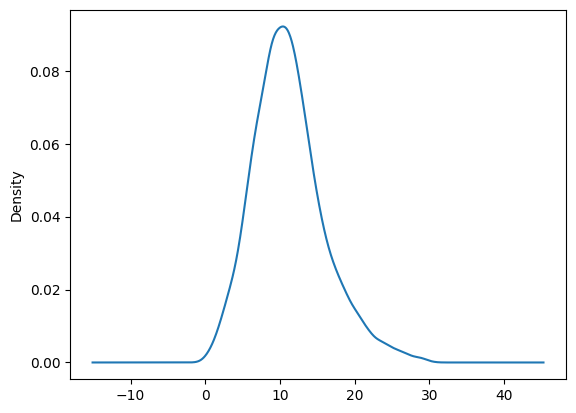

In [7]:
test_df['wind_speed_10m_kmh'].plot(kind='kde')

<Axes: ylabel='Density'>

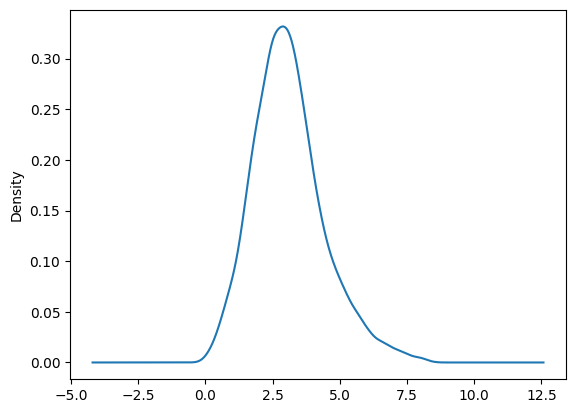

In [5]:
test_df['wind_speed_10m'].plot(kind='kde')

<Axes: xlabel='wind_direction_10m', ylabel='Count'>

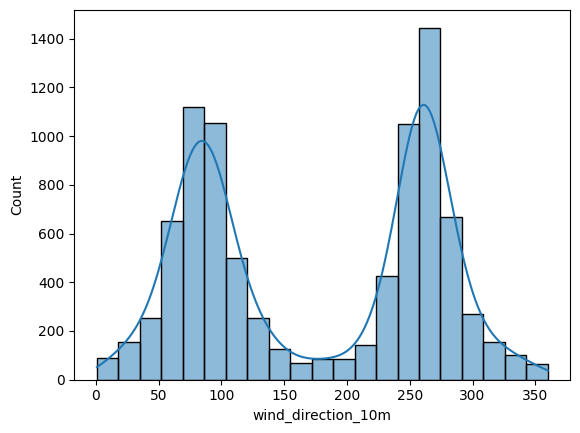

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(test_df['wind_direction_10m'], kde=True)

In [10]:
test_df.describe()

,wind_speed_10m,wind_direction_10m,wind_speed_10m_kmh
count,8760.000000,8760.000000,8760.000000
mean,3.098349,175.940070,11.154055
std,1.328958,94.019584,4.784249
min,0.000000,0.868040,0.000000
25%,2.196304,85.150961,7.906693
50%,2.965215,192.934805,10.674774
75%,3.820013,261.802955,13.752047
max,8.383615,360.000000,30.181016


In [11]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                8760 non-null   str    
 1   wind_speed_10m      8760 non-null   float64
 2   wind_direction_10m  8760 non-null   float64
 3   wind_speed_10m_kmh  8760 non-null   float64
dtypes: float64(3), str(1)
memory usage: 273.9 KB


In [16]:
pd.to_datetime(test_df['date'])

0      2025-01-01 00:00:00+00:00
1      2025-01-01 01:00:00+00:00
2      2025-01-01 02:00:00+00:00
3      2025-01-01 03:00:00+00:00
4      2025-01-01 04:00:00+00:00
                  ...           
8755   2025-12-31 19:00:00+00:00
8756   2025-12-31 20:00:00+00:00
8757   2025-12-31 21:00:00+00:00
8758   2025-12-31 22:00:00+00:00
8759   2025-12-31 23:00:00+00:00
Name: date, Length: 8760, dtype: datetime64[us, UTC]

In [ ]:
test_df=pd.read_csv('bengaluru_actual.csv')
t_df = pd.read_csv('bengaluru_forecast.csv')
x=test_df.merge(t_df, on = "date", suffixes = ("_actual", "_forecast"))

In [23]:
x['id']= "bengaluru"
x['name']= "Bengaluru"
x['longitude'] = 77.5937
x['latitude'] = 12.9719
x['terrain'] = "tropical"
x['elevation_m'] = 918
x.head()

,date,wind_speed_10m_actual,wind_direction_10m_actual,wind_speed_10m_forecast,wind_direction_10m_forecast,id,name,longitude,latitude,terrain,elevation_m
0,2025-01-01 00:00:00+00:00,3.084234,70.096160,1.746425,66.370610,bengaluru,Bengaluru,77.5937,12.9719,tropical,918
1,2025-01-01 01:00:00+00:00,3.166228,68.702576,1.431782,65.224880,bengaluru,Bengaluru,77.5937,12.9719,tropical,918
2,2025-01-01 02:00:00+00:00,3.036445,72.758450,1.392839,68.962420,bengaluru,Bengaluru,77.5937,12.9719,tropical,918
3,2025-01-01 03:00:00+00:00,2.934706,76.200490,2.213594,71.564964,bengaluru,Bengaluru,77.5937,12.9719,tropical,918
4,2025-01-01 04:00:00+00:00,3.510698,79.330270,3.383785,71.029500,bengaluru,Bengaluru,77.5937,12.9719,tropical,918


In [24]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         8760 non-null   str    
 1   wind_speed_10m_actual        8760 non-null   float64
 2   wind_direction_10m_actual    8760 non-null   float64
 3   wind_speed_10m_forecast      8760 non-null   float64
 4   wind_direction_10m_forecast  8760 non-null   float64
 5   id                           8760 non-null   str    
 6   name                         8760 non-null   str    
 7   longitude                    8760 non-null   float64
 8   latitude                     8760 non-null   float64
 9   terrain                      8760 non-null   str    
 10  elevation_m                  8760 non-null   int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 752.9 KB
